# 📊 Exploratory Data Analysis — Credit Card Fraud

**Goal of this notebook:** profile the raw data *before* any modelling, so that
every preprocessing and modelling decision later in the project is justified by
evidence rather than assumed.

This is the data-analysis stage of the project. It covers:

1. Dataset overview & data quality
2. Class balance (the central challenge of this problem)
3. Transaction `Amount` distribution
4. Temporal patterns — fraud rate by hour of day
5. Feature relationships with the fraud label
6. Key findings → how each one informs the modelling pipeline

> **Dataset:** [Kaggle — Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)
> (284,807 transactions, 492 fraud cases, features `V1`–`V28` are PCA components).
> Place `creditcard.csv` in `../data/` before running.


## 1. Setup & data loading

In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

DATA_PATH = "../data/creditcard.csv"

assert os.path.exists(DATA_PATH), (
    f"Dataset not found at {DATA_PATH}. Download creditcard.csv from "
    "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud and place it in data/."
)

df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} transactions x {df.shape[1]} columns")
df.head()

Loaded 284,807 transactions x 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Dataset overview & data quality

A quick profile: dimensions, data types, missing values, and basic statistics.
Clean data with no missing values means we can focus on the modelling challenge
(imbalance) rather than data repair.

In [21]:
print("Shape:", df.shape)
print("\nMissing values per column:", df.isnull().sum().sum(), "total")
print("\nColumn dtypes:")
print(df.dtypes.value_counts())

Shape: (284807, 31)

Missing values per column: 0 total

Column dtypes:
float64    30
int64       1
Name: count, dtype: int64


In [22]:
# Summary statistics for the human-readable columns
df[["Time", "Amount", "Class"]].describe()

,Time,Amount,Class
count,284807.000000,284807.000000,284807.000000
mean,94813.859575,88.349619,0.001727
std,47488.145955,250.120109,0.041527
min,0.000000,0.000000,0.000000
25%,54201.500000,5.600000,0.000000
50%,84692.000000,22.000000,0.000000
75%,139320.500000,77.165000,0.000000
max,172792.000000,25691.160000,1.000000


## 3. Class balance — the central challenge

In fraud detection the target is extremely imbalanced. Quantifying *how*
imbalanced drives three later decisions:

- **Metric choice** — accuracy is meaningless; we need precision / recall / F1.
- **Resampling** — a balancing step (SMOTETomek) on the training set is justified.
- **Threshold tuning** — the default 0.5 cut-off is unlikely to be optimal.

Legitimate : 284,315
Fraud      : 492  (0.173%)
Imbalance  : 578 : 1


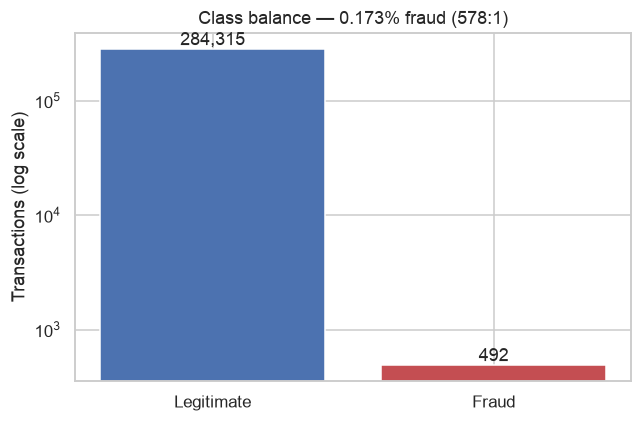

In [23]:
counts = df["Class"].value_counts().sort_index()
legit, fraud = int(counts[0]), int(counts[1])
fraud_pct = fraud / len(df) * 100
ratio = legit / fraud

print(f"Legitimate : {legit:,}")
print(f"Fraud      : {fraud:,}  ({fraud_pct:.3f}%)")
print(f"Imbalance  : {ratio:.0f} : 1")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Legitimate", "Fraud"], [legit, fraud], color=["#4C72B0", "#C44E52"])
ax.set_yscale("log")
ax.set_ylabel("Transactions (log scale)")
ax.set_title(f"Class balance — {fraud_pct:.3f}% fraud ({ratio:.0f}:1)")
for i, v in enumerate([legit, fraud]):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 4. Transaction amount distribution

`Amount` is heavily right-skewed — most transactions are small, with a long tail
of large ones. A log transform compresses this, which is why `AmountLog` is added
as an engineered feature. We also compare the distribution across the two classes.

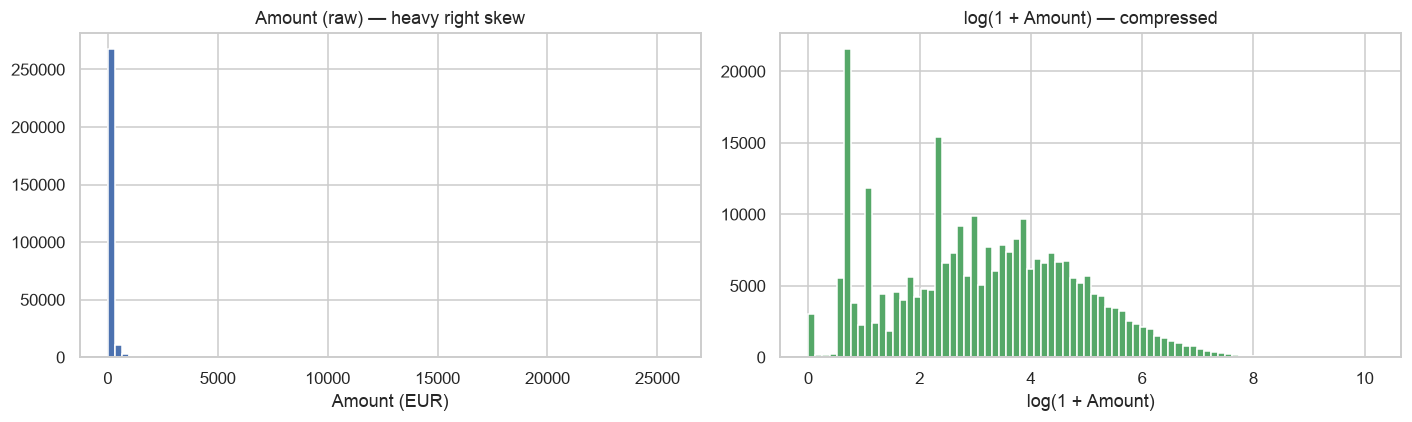

Median amount by class:
Class
Legitimate    22.00
Fraud          9.25
Name: Amount, dtype: float64


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["Amount"], bins=80, color="#4C72B0")
axes[0].set_title("Amount (raw) — heavy right skew")
axes[0].set_xlabel("Amount (EUR)")

axes[1].hist(np.log1p(df["Amount"]), bins=80, color="#55A868")
axes[1].set_title("log(1 + Amount) — compressed")
axes[1].set_xlabel("log(1 + Amount)")
plt.tight_layout()
plt.show()

print("Median amount by class:")
print(df.groupby("Class")["Amount"].median().rename({0: "Legitimate", 1: "Fraud"}))

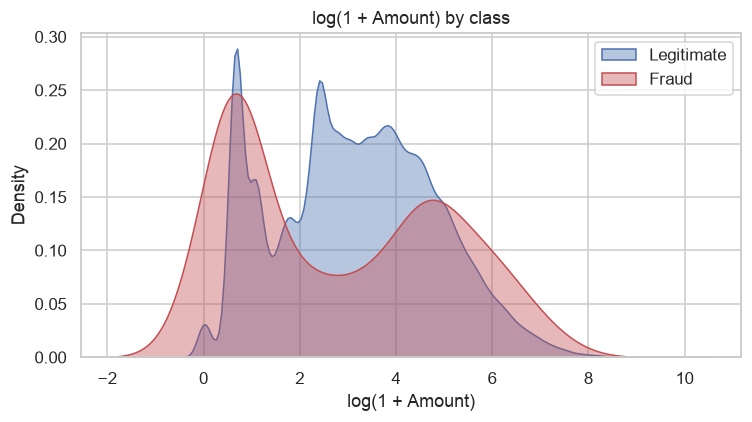

In [25]:
# Distribution of (log) amount split by class
fig, ax = plt.subplots(figsize=(7, 4))
for cls, name, color in [(0, "Legitimate", "#4C72B0"), (1, "Fraud", "#C44E52")]:
    sns.kdeplot(np.log1p(df.loc[df["Class"] == cls, "Amount"]),
                label=name, fill=True, alpha=0.4, color=color, ax=ax)
ax.set_title("log(1 + Amount) by class")
ax.set_xlabel("log(1 + Amount)")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Temporal patterns — fraud rate by hour

The raw `Time` field is just elapsed seconds. Converting it to hour-of-day exposes
behavioural patterns. Crucially we look at the fraud **rate** per hour (fraud as a
share of that hour's transactions), not the raw count — counts mostly track overall
transaction volume and would be misleading. This pattern is the rationale for the
`Hour` and `DaySegment` engineered features.

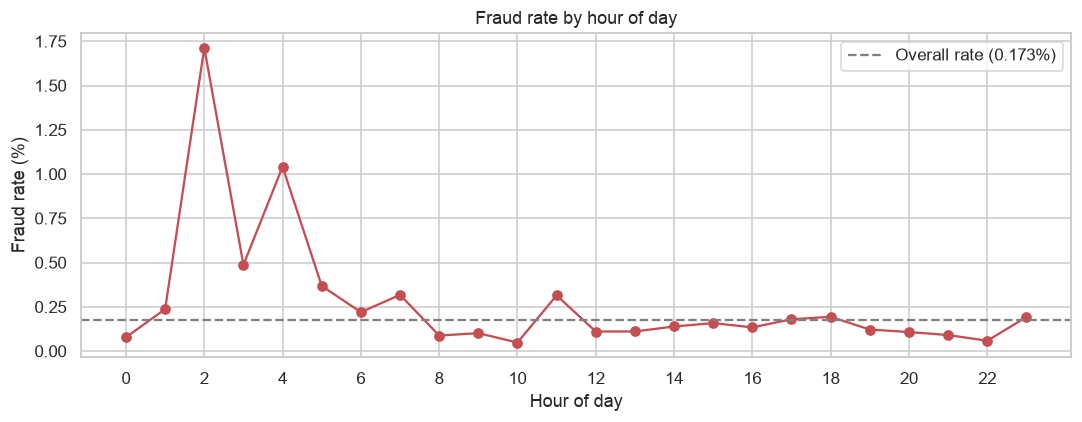

Highest fraud rate at hour 2: 1.713% (vs 0.173% overall)


In [26]:
df_h = df.assign(Hour=(df["Time"] % 86400) // 3600)
rate_by_hour = df_h.groupby("Hour")["Class"].mean() * 100
overall = df["Class"].mean() * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rate_by_hour.index, rate_by_hour.values, marker="o", color="#C44E52")
ax.axhline(overall, ls="--", color="gray", label=f"Overall rate ({overall:.3f}%)")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Fraud rate (%)")
ax.set_title("Fraud rate by hour of day")
ax.set_xticks(range(0, 24, 2))
ax.legend()
plt.tight_layout()
plt.show()

peak = int(rate_by_hour.idxmax())
print(f"Highest fraud rate at hour {peak}: {rate_by_hour.max():.3f}% "
      f"(vs {overall:.3f}% overall)")

## 6. Which features relate most to fraud?

A quick linear screen: absolute Pearson correlation of each feature with the
`Class` label. The PCA components `V1`–`V28` are anonymised, but several show a
clear relationship — these tend to be the ones the model leans on, and they line
up with the later SHAP importance analysis.

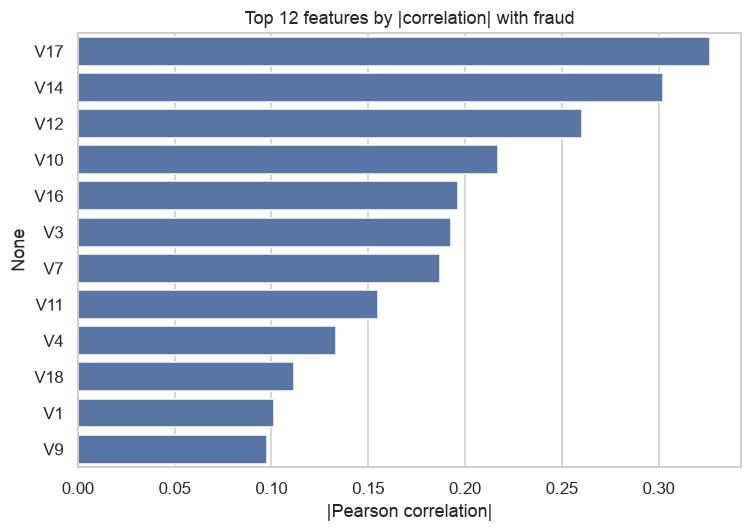

V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
Name: Class, dtype: float64

In [27]:
corr = df.corr(numeric_only=True)["Class"].drop("Class")
top = corr.abs().sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=top.values, y=top.index, color="#4C72B0", ax=ax)
ax.set_title("Top 12 features by |correlation| with fraud")
ax.set_xlabel("|Pearson correlation|")
plt.tight_layout()
plt.show()

top.head(6)

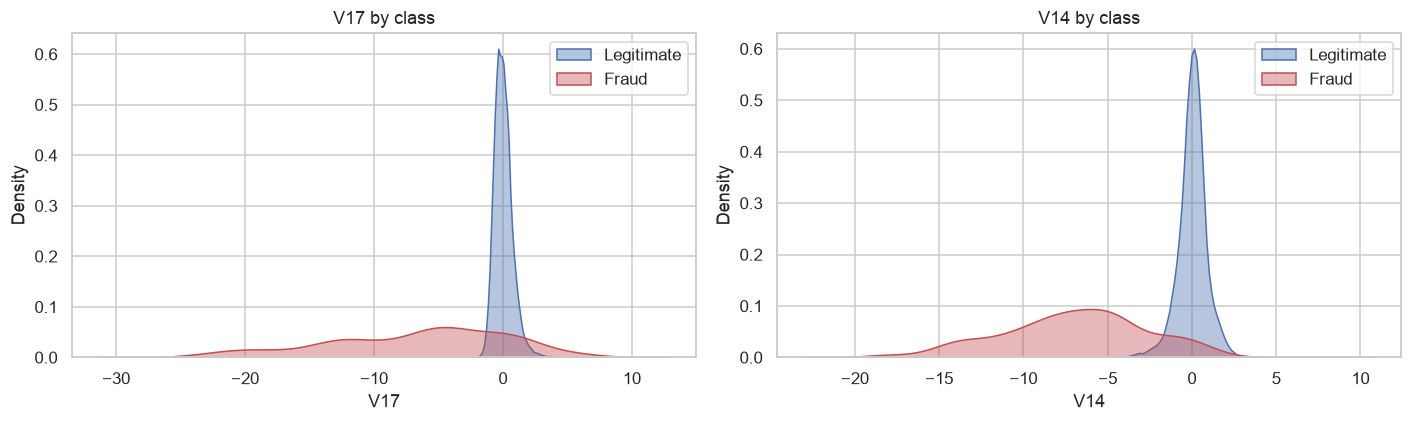

In [28]:
# Distribution of the two strongest signals, split by class
strongest = list(top.head(2).index)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, feat in zip(axes, strongest):
    for cls, name, color in [(0, "Legitimate", "#4C72B0"), (1, "Fraud", "#C44E52")]:
        sns.kdeplot(df.loc[df["Class"] == cls, feat], label=name,
                    fill=True, alpha=0.4, color=color, ax=ax)
    ax.set_title(f"{feat} by class")
    ax.legend()
plt.tight_layout()
plt.show()

## 7. Key findings → modelling decisions

Summarising the analysis as decisions — the way an analyst hands work to the next
stage:

| # | Finding | Decision it drives |
|---|---------|--------------------|
| 1 | Severe class imbalance (~0.17% fraud, ~577:1) | Use precision/recall/F1, not accuracy; apply resampling on the training set only |
| 2 | `Amount` is heavily right-skewed | Add a log-transformed `AmountLog` feature |
| 3 | Fraud rate varies by hour of day | Engineer `Hour` and `DaySegment` features |
| 4 | A handful of PCA components correlate strongly with fraud | Expect these to dominate feature importance; confirm later with SHAP |
| 5 | No missing values, clean types | No imputation needed; effort goes to imbalance, not repair |

**Skills demonstrated:** exploratory data analysis · data profiling & quality checks ·
statistical summarisation · data visualisation (Matplotlib, Seaborn) · pandas ·
translating analysis into actionable decisions.

> ℹ️ Run this notebook end-to-end on your local `creditcard.csv`, then commit it
> with outputs so the charts render on the GitHub page.
